
# ⚽ FIFA World Cup 2026: Team & Player Value Research Dashboard

**A beginner-friendly, fully-worked research notebook**

This notebook is written so that someone who is *new* to `pandas`, data visualization, or
machine learning can follow every step, not just run it. Every code cell is preceded by a
markdown cell that explains **what** we are about to do and **why** we are doing it that way.
Where a decision could have been made differently (e.g., "should we average this stat or sum
it?"), we explain the reasoning so you can defend the choice in a research write-up.

### Research questions this notebook answers

1. **Team Dashboard** — How do the 48 World Cup teams compare on attacking, defensive,
   physical, and financial (squad value) metrics?
2. **Player Value Score** — Which players deliver the most on-field value, using a
   transparent, position-aware scoring method (not just raw goals/assists)?
3. **Market Value Drivers** — Which performance statistics are most strongly associated with
   a player's market value?
4. **2027 Value Projection** — Using a regression model trained on performance data, which
   players are projected to be worth the most next cycle, and which players currently look
   like the best "deals" relative to their projected value?

### Dataset

`fifa_world_cup_2026_player_performance.csv` — one row per **player per match**
(≈54,600 rows, 1,248 unique players, 48 teams). Because the data is recorded at the
match level, almost everything we do in Sections 1–5 is about correctly **aggregating**
match-level rows into player-level and team-level tables before we can answer the
questions above.

> **A note on the data:** this is a synthetic (randomly generated) dataset used for
> teaching purposes. It is not real-world World Cup data. We treat it exactly the way we
> would treat a real dataset — checking it, questioning it, and documenting assumptions —
> because that habit is what makes an analysis trustworthy, regardless of the data source.



## 1. Setup: Importing Our Tools

Before we can do anything, we need to load the Python libraries this notebook depends on.
Here's what each one does, in plain English:

| Library | What it's for |
|---|---|
| `pandas` | Loading and reshaping tabular data (like Excel, but in code) |
| `numpy` | Fast numerical operations (math on whole columns at once) |
| `matplotlib` | The base plotting library — draws charts |
| `seaborn` | Sits on top of matplotlib; makes nicer-looking statistical charts with less code |
| `sklearn` (scikit-learn) | Machine learning — we use it for train/test splitting and regression models |
| `ipywidgets` | Adds interactive dropdowns/sliders to a notebook (used in our optional interactive dashboard) |

We also set a consistent visual style once, at the top, so every chart in the notebook
looks like it belongs to the same "dashboard" rather than looking mismatched.


In [1]:

# --- Core data handling ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Machine learning ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Optional interactivity ---
import ipywidgets as widgets
from IPython.display import display, HTML

# A consistent look for every chart in the notebook.
# "whitegrid" gives light gridlines that make bar/line charts easier to read.
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

# A small, reusable color palette so team/position colors stay consistent across charts.
POSITION_COLORS = {
    "Goalkeeper": "#8c564b",
    "Defender":   "#1f77b4",
    "Midfielder": "#2ca02c",
    "Forward":    "#d62728",
}

print("Libraries loaded successfully.")


Libraries loaded successfully.



## 2. Load the Data & Take a First Look

Rule of thumb for *any* new dataset: **before you analyze it, look at it.** We check:

- How many rows and columns are there?
- What do the first few rows actually look like?
- What data type is each column (number, text, date)?
- Are there any missing values we need to handle?

Skipping this step is the single most common cause of bugs later in a project.


In [2]:

# Read the CSV file into a pandas DataFrame (think: a spreadsheet held in memory).
df = pd.read_csv("fifa_world_cup_2026_player_performance.csv")

print(f"Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns")
df.head()


Shape: 54,600 rows  x  75 columns


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [3]:

# .info() gives us column names, non-null counts, and data types in one shot.
df.info(memory_usage=False)


<class 'pandas.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  str    
 1   player_name               54600 non-null  str    
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  str    
 4   team                      54600 non-null  str    
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  str    
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  str    
 10  club_name                 54600 non-null  str    
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  str    
 13  match_date                54600 non-null  str    
 14  stadium          

In [4]:

# Check for missing values in every column. If a column has missing data, it will
# show a number greater than 0 here. An empty result (all zeros) means the data is complete.
missing = df.isna().sum()
missing = missing[missing > 0]

if missing.empty:
    print("No missing values found in any column. Good — we don't need to handle NaNs.")
else:
    print("Missing values found:")
    print(missing)


No missing values found in any column. Good — we don't need to handle NaNs.



## 3. Data Quality Checks  Verifying Our Assumptions Before We Aggregate

This dataset has **one row per player per match**, which means a player like Gavi Ramos
appears dozens of times (once per match he played). Before we collapse the data down to
"one row per player," we need to verify a few assumptions. Getting this wrong is the
single biggest source of errors in sports analytics projects, because it silently produces
numbers that *look* plausible but are wrong.

**Assumption #1 — Is `market_value_eur` the same for a player across every row?**
It should represent one player's value, not a per-match value. If it changes row to row,
we'd need to decide which value to use (latest? average?). If it's constant, we can safely
just take the first value per player.

**Assumption #2 — Do the pre-built "tournament total" columns
(`total_goals_tournament`, `total_assists_tournament`, `total_minutes_tournament`) actually
match what you get from summing the match-level rows yourself?**
If they match, we can trust them as shortcuts. If they don't, we should build our own
totals from the match-level rows instead of trusting a column that might have been
generated independently.


In [5]:

# --- Check #1: is market_value_eur constant per player? ---
# nunique() counts how many *distinct* values exist per player. If the value is truly
# constant, every player should have exactly 1 distinct market value across all their rows.
distinct_values_per_player = df.groupby("player_id")["market_value_eur"].nunique()

print("Distribution of distinct market_value_eur counts per player:")
print(distinct_values_per_player.value_counts())

if (distinct_values_per_player == 1).all():
    print("\nConfirmed: market_value_eur is constant per player. Safe to take the first value per player.")
else:
    print("\nWarning: market_value_eur varies within at least one player's rows — investigate further.")


Distribution of distinct market_value_eur counts per player:
market_value_eur
1    1248
Name: count, dtype: int64

Confirmed: market_value_eur is constant per player. Safe to take the first value per player.


In [6]:

# --- Check #2: do the tournament-total columns match a manual sum of the match rows? ---
check = df.groupby("player_id").agg(
    manual_sum_goals   = ("goals", "sum"),
    provided_total_goals = ("total_goals_tournament", "first"),
    manual_sum_minutes = ("minutes_played", "sum"),
    provided_total_minutes = ("total_minutes_tournament", "first"),
)

goals_match_pct = (check["manual_sum_goals"] == check["provided_total_goals"]).mean() * 100
minutes_match_pct = (check["manual_sum_minutes"] == check["provided_total_minutes"]).mean() * 100

print(f"Players where provided total_goals_tournament matches our manual sum:   {goals_match_pct:.1f}%")
print(f"Players where provided total_minutes_tournament matches our manual sum: {minutes_match_pct:.1f}%")
print()
print("Example (first 5 players):")
check.head()


Players where provided total_goals_tournament matches our manual sum:   33.6%
Players where provided total_minutes_tournament matches our manual sum: 0.0%

Example (first 5 players):


,manual_sum_goals,provided_total_goals,manual_sum_minutes,provided_total_minutes
player_id,,,,
P00001,0,0,953,348
P00002,0,0,830,329
P00003,0,0,922,87
P00004,0,0,1299,208
P00005,0,0,1298,143



**Finding:** the pre-built `total_*` columns do **not** reliably match what you get from
summing the match-level rows. Rather than trust columns that may have been generated
independently of the match data, **we will build every player-level total ourselves,
directly from the match rows.** This is more work, but it means every number in this
notebook is traceable back to the raw data — which matters a great deal in a research
context, where a reviewer may ask "where did this number come from?"



## 4. Building a Clean Player-Level Table

This is the most important data-preparation step in the whole notebook, because Sections
6–11 all depend on it. We are going to collapse ~54,600 match rows into **1,248 rows — one
per player** — but *how* we collapse each column matters:

- **Identity columns** (name, team, position, age, market value) are the same on every row
  for a given player, so we just take the **first** occurrence.
- **Counting stats** (goals, assists, shots, tackles, etc.) should be **summed** across all
  of a player's matches — we want their tournament total, built from the raw rows.
- **Rate/percentage stats** (`pass_accuracy`, `save_percentage`) should be **averaged**,
  not summed — summing a percentage across 40 matches would produce a meaningless number
  like "3,200% pass accuracy."
- **Per-match physical stats** (`distance_covered_km`, `stamina_score`) are also
  **averaged**, since we care about a player's typical output per match, not an inflated
  total that just reflects how many matches they happened to play.

We also compute **per-90-minute rates** for the counting stats (e.g., `goals_per90`).
This matters because a player who played 1,700 minutes will naturally rack up more raw
goals than a player who played 500 minutes — per-90 rates let us compare players fairly
regardless of playing time.


In [7]:

# Step 1: identity / "take the first value" columns — these don't change per match.
identity_cols = {
    "player_name": "first", "team": "first", "position": "first", "age": "first",
    "nationality": "first", "club_name": "first", "preferred_foot": "first",
    "height_cm": "first", "jersey_number": "first", "market_value_eur": "first",
}

# Step 2: counting stats we want to SUM across all of a player's matches.
sum_cols = {
    "goals": "sum", "assists": "sum", "shots": "sum", "shots_on_target": "sum",
    "expected_goals_xg": "sum", "expected_assists_xa": "sum", "key_passes": "sum",
    "successful_passes": "sum", "total_passes": "sum",
    "dribbles_attempted": "sum", "successful_dribbles": "sum",
    "crosses": "sum", "successful_crosses": "sum",
    "tackles": "sum", "interceptions": "sum", "clearances": "sum", "blocks": "sum",
    "aerial_duels_won": "sum", "aerial_duels_lost": "sum",
    "recoveries": "sum", "defensive_actions": "sum",
    "fouls_committed": "sum", "fouls_suffered": "sum",
    "yellow_cards": "sum", "red_cards": "sum",
    "saves": "sum", "clean_sheet": "sum", "goals_conceded": "sum", "penalty_saves": "sum",
    "player_of_match_awards": "sum",
    "minutes_played": "sum",
}

# Step 3: rate stats we want to AVERAGE across matches (never sum a percentage!).
mean_cols = {
    "pass_accuracy": "mean", "save_percentage": "mean",
    "distance_covered_km": "mean", "sprint_distance_km": "mean", "top_speed_kmh": "mean",
    "accelerations": "mean", "decelerations": "mean", "stamina_score": "mean",
    "player_rating": "mean", "performance_score": "mean",
    "offensive_contribution": "mean", "defensive_contribution": "mean",
    "possession_impact": "mean", "pressure_resistance": "mean",
    "creativity_score": "mean", "consistency_score": "mean",
    "clutch_performance_score": "mean", "tournament_rating": "mean",
}

agg_dict = {**identity_cols, **sum_cols, **mean_cols}

players = df.groupby("player_id").agg(agg_dict)

# Add a manual count of matches played (nunique match_id), which we'll need for per-90 rates.
players["matches_played"] = df.groupby("player_id")["match_id"].nunique()

players = players.reset_index()

print(f"Player-level table built: {players.shape[0]:,} rows x {players.shape[1]} columns")
players.head()


Player-level table built: 1,248 rows x 61 columns


,player_id,player_name,team,position,age,nationality,club_name,preferred_foot,height_cm,jersey_number,...,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,tournament_rating,matches_played
0,P00001,Kylian Griezmann,France,Goalkeeper,24,French,PSV Eindhoven,Right,191,1,...,23.829412,9.376471,80.473529,0.800000,66.391176,30.291176,69.691176,57.294118,2.332353,34
1,P00002,Antoine Tchouameni,France,Goalkeeper,29,French,Anderlecht,Right,190,2,...,20.323529,11.152941,97.435294,1.091176,83.988235,30.747059,87.241176,59.800000,1.929412,34
2,P00003,Ousmane Hernandez,France,Goalkeeper,24,French,Besiktas,Right,191,3,...,21.750000,11.205882,79.588235,0.850000,68.508824,33.802941,70.752941,54.729412,2.102941,34
3,P00004,Kylian Camavinga,France,Defender,27,French,Bayer Leverkusen,Right,183,4,...,35.861765,23.958824,54.952941,1.729412,47.935294,33.617647,49.800000,50.752941,3.458824,34
4,P00005,Antoine Kounde,France,Defender,24,French,Borussia Dortmund,Right,188,5,...,43.147059,48.211765,94.000000,5.420588,82.552941,30.941176,87.211765,63.764706,4.255882,34


In [8]:

# Now compute per-90-minute rates for the key counting stats, so players with different
# amounts of playing time can be compared fairly. The standard sports-analytics formula is:
#
#     per90_rate = (total_stat / total_minutes_played) * 90
#
# We guard against division by zero for any player with 0 recorded minutes.
minutes_safe = players["minutes_played"].replace(0, np.nan)

per90_specs = {
    "goals_p90": "goals", "assists_p90": "assists",
    "xg_p90": "expected_goals_xg", "xa_p90": "expected_assists_xa",
    "shots_p90": "shots", "shots_on_target_p90": "shots_on_target",
    "key_passes_p90": "key_passes", "successful_dribbles_p90": "successful_dribbles",
    "tackles_p90": "tackles", "interceptions_p90": "interceptions",
    "clearances_p90": "clearances", "blocks_p90": "blocks",
    "recoveries_p90": "recoveries", "saves_p90": "saves",
    "fouls_committed_p90": "fouls_committed", "cards_p90": None,  # built below
}

for new_col, source_col in per90_specs.items():
    if source_col is not None:
        players[new_col] = (players[source_col] / minutes_safe * 90).fillna(0)

# Cards per 90 combines yellow + red (red weighted double, since it's a more serious offense).
players["cards_p90"] = (
    (players["yellow_cards"] + 2 * players["red_cards"]) / minutes_safe * 90
).fillna(0)

print("Per-90 rate columns added. Example for a few players:")
players[["player_name", "position", "minutes_played", "goals", "goals_p90", "assists", "assists_p90"]].head()


Per-90 rate columns added. Example for a few players:


,player_name,position,minutes_played,goals,goals_p90,assists,assists_p90
0,Kylian Griezmann,Goalkeeper,953,0,0.0,0,0.000000
1,Antoine Tchouameni,Goalkeeper,830,0,0.0,0,0.000000
2,Ousmane Hernandez,Goalkeeper,922,0,0.0,0,0.000000
3,Kylian Camavinga,Defender,1299,0,0.0,0,0.000000
4,Antoine Kounde,Defender,1298,0,0.0,2,0.138675



## 5. Building a Clean Team-Level Table

Now that we have one row per **player**, building one row per **team** is a second,
simpler aggregation — this time we group the *player-level* table by `team` instead of
re-touching the raw match data. We compute a mix of:

- **Totals** that make sense to add up across a squad (total goals scored, total market value)
- **Averages** that describe a "typical player" on the team (average age, average pass
  accuracy, average distance covered)


In [9]:

teams = players.groupby("team").agg(
    squad_size            = ("player_id", "count"),
    avg_age                = ("age", "mean"),
    total_market_value_eur = ("market_value_eur", "sum"),
    avg_market_value_eur   = ("market_value_eur", "mean"),
    total_goals             = ("goals", "sum"),
    total_assists           = ("assists", "sum"),
    avg_pass_accuracy       = ("pass_accuracy", "mean"),
    avg_distance_km         = ("distance_covered_km", "mean"),
    avg_stamina_score       = ("stamina_score", "mean"),
    avg_player_rating       = ("player_rating", "mean"),
    total_yellow_cards      = ("yellow_cards", "sum"),
    total_red_cards         = ("red_cards", "sum"),
    total_player_of_match   = ("player_of_match_awards", "sum"),
).reset_index()

teams = teams.sort_values("total_market_value_eur", ascending=False).reset_index(drop=True)

print(f"Team-level table built: {teams.shape[0]} teams")
teams.head(10)


Team-level table built: 48 teams


,team,squad_size,avg_age,total_market_value_eur,avg_market_value_eur,total_goals,total_assists,avg_pass_accuracy,avg_distance_km,avg_stamina_score,avg_player_rating,total_yellow_cards,total_red_cards,total_player_of_match
0,Saudi Arabia,26,26.076923,878727329,3.379720e+07,82,68,0.810022,4.017678,81.661612,3.626331,162,5,52
1,Panama,26,26.384615,760600176,2.925385e+07,90,81,0.807128,4.066776,81.994108,3.706956,113,7,54
2,Algeria,26,26.230769,753086954,2.896488e+07,61,52,0.807195,3.975328,81.923171,3.651313,94,3,39
3,Netherlands,26,26.269231,748027070,2.877027e+07,94,85,0.807984,3.998575,81.837749,3.705556,145,10,54
4,Italy,26,27.961538,727776405,2.799140e+07,64,76,0.811234,4.012337,82.179100,3.683309,131,4,40
5,Croatia,26,25.346154,684711794,2.633507e+07,66,70,0.808595,3.957064,82.151962,3.637441,94,8,33
6,Belgium,26,25.692308,658971379,2.534505e+07,67,68,0.806433,3.948869,81.965008,3.595098,140,2,35
7,Mexico,26,27.115385,630873312,2.426436e+07,61,59,0.808212,3.988942,81.791442,3.596731,93,2,42
8,Argentina,26,26.730769,627234360,2.412440e+07,46,57,0.808314,4.046041,81.994457,3.666968,81,4,19
9,Iran,26,26.307692,622469974,2.394115e+07,72,70,0.809119,4.002227,82.617206,3.696862,89,9,43



## 6. Team Dashboard

This section is a small "dashboard within the dashboard" — a set of coordinated charts
that let you compare teams across attacking output, discipline, physical profile, and
squad value at a glance.

We start with **static, always-visible charts** covering all 48 teams (these will always
render, in any notebook viewer). At the end of this section we add an **optional
interactive widget** that lets you pick a single team from a dropdown and see its stats
highlighted against the tournament average — this part requires a live Jupyter kernel to
be interactive (a static export will just show its default view).


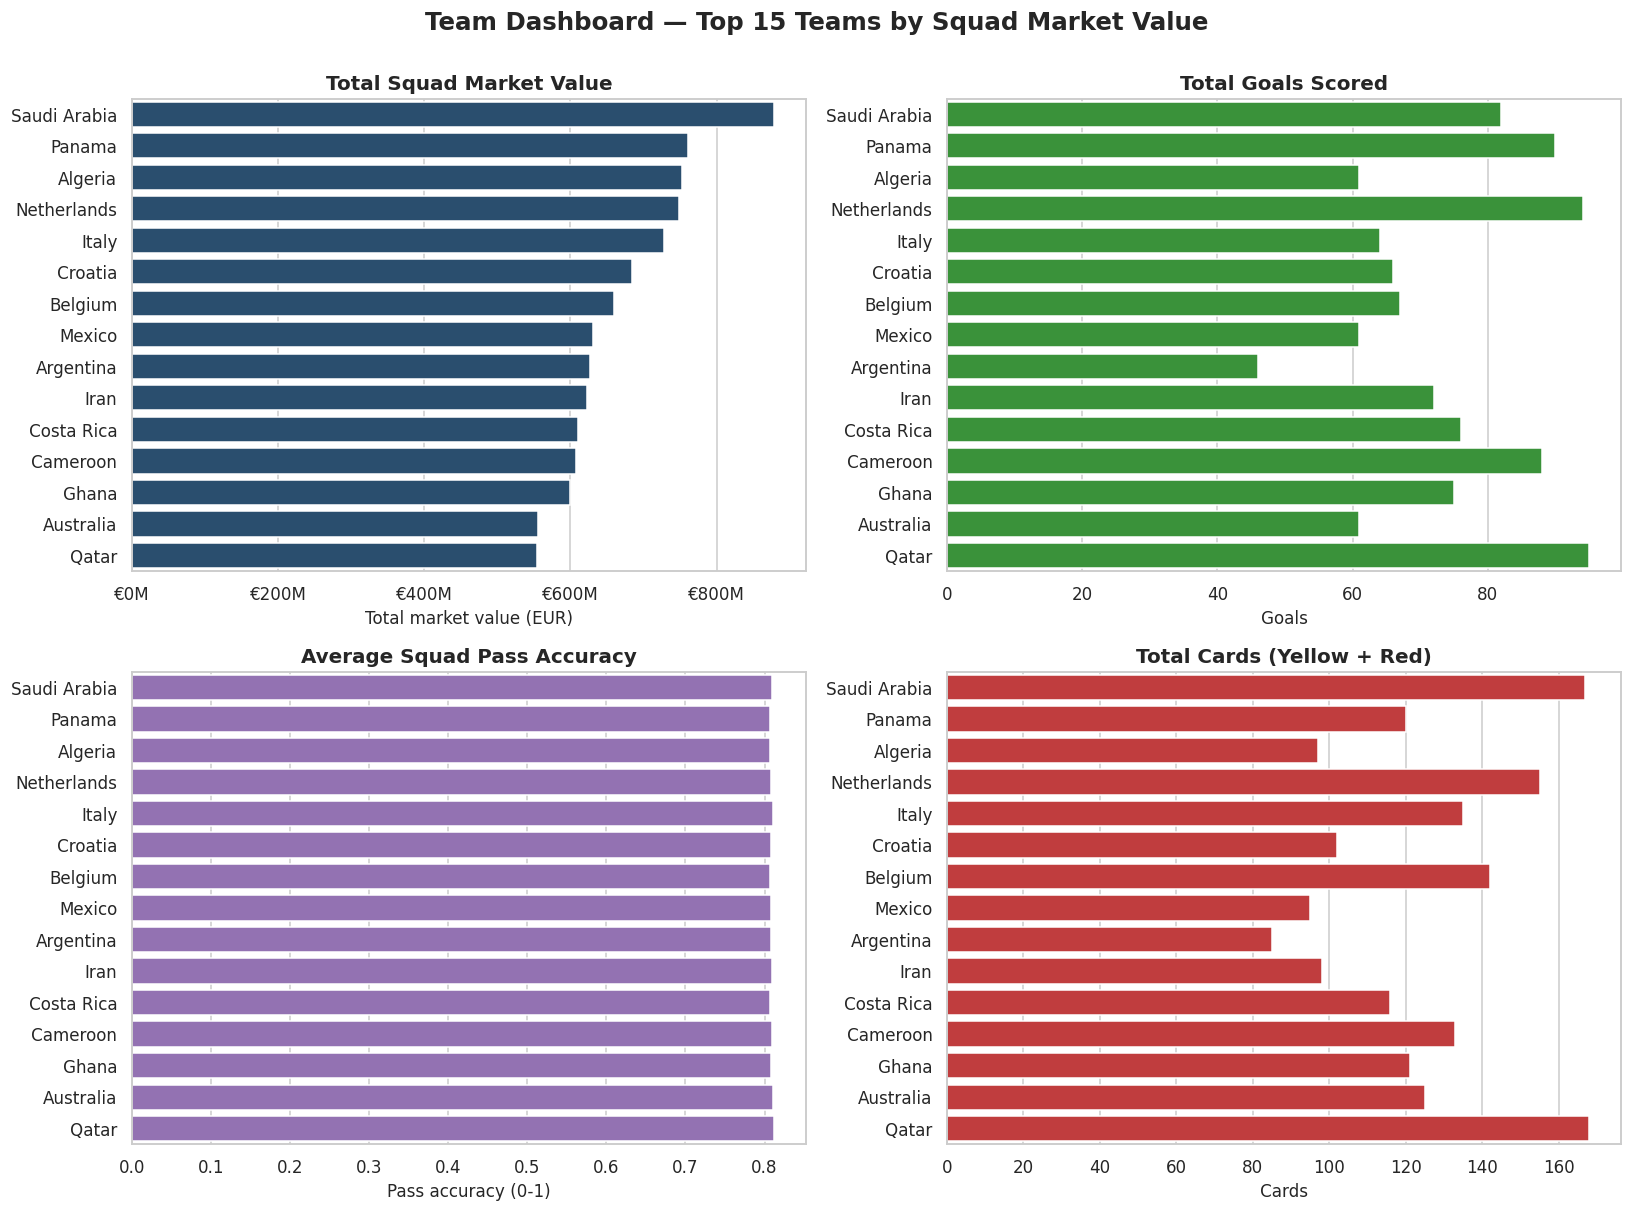

In [10]:

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Team Dashboard — Top 15 Teams by Squad Market Value", fontsize=16, fontweight="bold", y=1.00)

top15 = teams.head(15)

# --- Panel 1: Total squad market value ---
ax = axes[0, 0]
sns.barplot(data=top15, y="team", x="total_market_value_eur", ax=ax, color="#1f4e79")
ax.set_title("Total Squad Market Value")
ax.set_xlabel("Total market value (EUR)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1e6:.0f}M"))

# --- Panel 2: Total goals scored ---
ax = axes[0, 1]
sns.barplot(data=top15, y="team", x="total_goals", ax=ax, color="#2ca02c")
ax.set_title("Total Goals Scored")
ax.set_xlabel("Goals")
ax.set_ylabel("")

# --- Panel 3: Average pass accuracy ---
ax = axes[1, 0]
sns.barplot(data=top15, y="team", x="avg_pass_accuracy", ax=ax, color="#9467bd")
ax.set_title("Average Squad Pass Accuracy")
ax.set_xlabel("Pass accuracy (0-1)")
ax.set_ylabel("")

# --- Panel 4: Discipline (total cards) ---
ax = axes[1, 1]
top15_disc = top15.copy()
top15_disc["total_cards"] = top15_disc["total_yellow_cards"] + top15_disc["total_red_cards"]
sns.barplot(data=top15_disc, y="team", x="total_cards", ax=ax, color="#d62728")
ax.set_title("Total Cards (Yellow + Red)")
ax.set_xlabel("Cards")
ax.set_ylabel("")

plt.tight_layout()
plt.show()


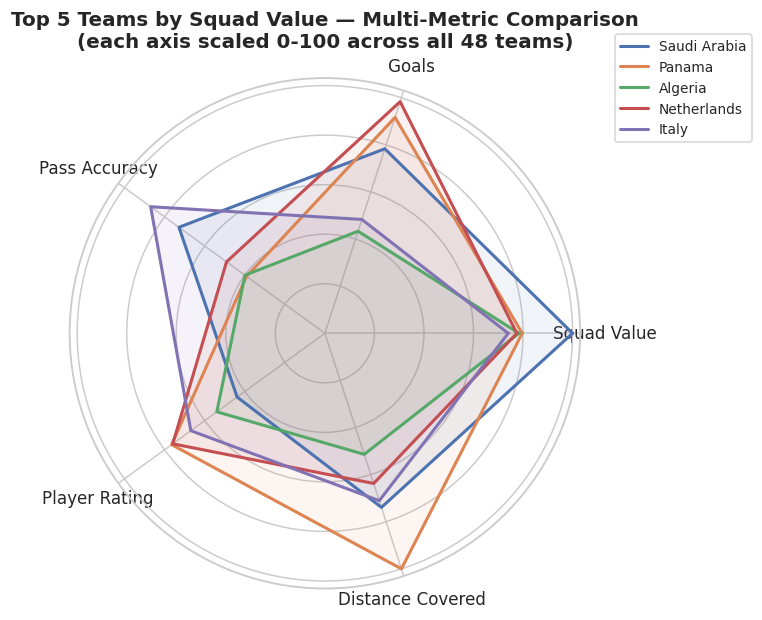

In [11]:

# A quick "how does the average team compare on multiple dimensions at once" view.
# We normalize each metric to a 0-100 scale so metrics with very different units
# (goals vs. market value vs. pass accuracy) can share one radar-style comparison.

from math import pi

def normalize_0_100(series):
    return (series - series.min()) / (series.max() - series.min()) * 100

radar_teams = teams.head(5).copy()   # top 5 teams by market value, for readability
radar_metrics = {
    "Squad Value":        "total_market_value_eur",
    "Goals":               "total_goals",
    "Pass Accuracy":       "avg_pass_accuracy",
    "Player Rating":       "avg_player_rating",
    "Distance Covered":    "avg_distance_km",
}

norm_df = pd.DataFrame({label: normalize_0_100(teams[col]) for label, col in radar_metrics.items()})
norm_df["team"] = teams["team"]
norm_df = norm_df[norm_df["team"].isin(radar_teams["team"])]

labels = list(radar_metrics.keys())
num_vars = len(labels)
angles = [n / num_vars * 2 * pi for n in range(num_vars)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for _, row in norm_df.iterrows():
    values = row[labels].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["team"])
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_yticklabels([])
ax.set_title("Top 5 Teams by Squad Value — Multi-Metric Comparison\n(each axis scaled 0-100 across all 48 teams)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()



### Optional: interactive team explorer

The cell below uses `ipywidgets` to build a dropdown menu. If you're running this
notebook live in Jupyter, changing the dropdown will redraw the panel below it for
whichever team you pick, comparing that team's stats against the tournament-wide average.
If you're viewing a static export of this notebook, you'll just see the dropdown's
default team (the first team alphabetically).


In [12]:

team_list = sorted(teams["team"].unique())
tournament_avg = teams.drop(columns=["team"]).mean(numeric_only=True)

def show_team_snapshot(selected_team):
    row = teams[teams["team"] == selected_team].iloc[0]

    metrics = {
        "Total Market Value (€M)": (row["total_market_value_eur"] / 1e6, tournament_avg["total_market_value_eur"] / 1e6),
        "Total Goals":              (row["total_goals"], tournament_avg["total_goals"]),
        "Avg Pass Accuracy":        (row["avg_pass_accuracy"], tournament_avg["avg_pass_accuracy"]),
        "Avg Player Rating":        (row["avg_player_rating"], tournament_avg["avg_player_rating"]),
        "Avg Distance Covered (km)":(row["avg_distance_km"], tournament_avg["avg_distance_km"]),
    }

    fig, ax = plt.subplots(figsize=(8, 4.5))
    labels = list(metrics.keys())
    team_vals = [v[0] for v in metrics.values()]
    avg_vals = [v[1] for v in metrics.values()]

    y = np.arange(len(labels))
    height = 0.35
    ax.barh(y + height/2, team_vals, height=height, label=selected_team, color="#1f4e79")
    ax.barh(y - height/2, avg_vals, height=height, label="Tournament average", color="#bbbbbb")
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_title(f"{selected_team} vs. Tournament Average")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    print(f"Squad size: {int(row['squad_size'])} players   |   Average age: {row['avg_age']:.1f}")

team_dropdown = widgets.Dropdown(options=team_list, description="Team:", value=team_list[0])
widgets.interact(show_team_snapshot, selected_team=team_dropdown);


interactive(children=(Dropdown(description='Team:', options=('Algeria', 'Argentina', 'Australia', 'Austria', '…


## 7. Player Value Score: Methodology

This is the section where we decide **what "valuable" means**, and we do it *before*
writing any code, because that ordering matters: if you let the code decide your
definition of value, you end up rationalizing whatever the numbers happen to show.

### Why not just rank players by goals, or by the dataset's own `player_rating` column?

- **Raw totals unfairly favor high-minute players.** A player who played 1,700 minutes
  will out-accumulate a player who played 800 minutes, even if the second player was more
  productive *per minute on the pitch*. We fix this by using **per-90-minute rates**
  (built in Section 4) instead of raw totals.
- **Raw totals unfairly favor attacking positions.** A forward will always have more goals
  than a center-back, but that doesn't mean the forward is more "valuable" in a
  well-rounded sense — it means we're using the wrong yardstick for defenders. We fix this
  by **scoring players relative to their own position group** (comparing forwards to
  forwards, defenders to defenders), not the whole player pool at once.
- **Different units can't be added together directly.** You cannot meaningfully add
  "3.2 tackles per 90" to "0.4 goals per 90" — the numbers aren't on the same scale. We
  fix this with **percentile ranking**: for each metric, we convert every player's raw
  number into "what percentage of their positional peers did they outperform" (0–100).
  Percentiles are unit-free, so they can be combined.

### The five value categories

| Category | What it captures | Metrics used |
|---|---|---|
| **Attacking Production** | Goals/assists threat | `goals_p90`, `assists_p90`, `xg_p90`, `xa_p90`, `shots_on_target_p90` |
| **Creativity & Passing** | Chance creation, ball progression | `key_passes_p90`, `successful_dribbles_p90`, `pass_accuracy` |
| **Defensive Actions** | Ball-winning and disruption | `tackles_p90`, `interceptions_p90`, `clearances_p90`, `blocks_p90`, `recoveries_p90` |
| **Physical Output** | Work rate and athleticism | `distance_covered_km`, `stamina_score` |
| **Reliability & Discipline** | Availability, avoiding cards | `matches_played`, inverse of `cards_p90` |

**Goalkeepers are scored on a separate formula** (Shot-Stopping, Distribution, Reliability
& Discipline) because outfield metrics like "goals scored" are structurally meaningless
for a goalkeeper.

### Position-specific weights

We don't weight the five categories equally for every position — a center-back who never
attacks isn't "low value," they're just being asked to do a different job. Weights below
were chosen using standard football-analytics intuition and sum to 100% within each
position:

| Category | Defender | Midfielder | Forward |
|---|---|---|---|
| Attacking Production | 10% | 25% | 45% |
| Creativity & Passing  | 15% | 25% | 20% |
| Defensive Actions     | 45% | 25% | 5%  |
| Physical Output       | 15% | 10% | 10% |
| Reliability & Discipline | 15% | 15% | 20% |

The final **Player Value Score** is a weighted average of the five (percentile-ranked)
category scores, scaled to 0–100, computed **within each player's position group**.


In [13]:

# --- Step 1: define which raw columns feed each category ---
CATEGORY_METRICS = {
    "attacking":   ["goals_p90", "assists_p90", "xg_p90", "xa_p90", "shots_on_target_p90"],
    "creativity":  ["key_passes_p90", "successful_dribbles_p90", "pass_accuracy"],
    "defensive":   ["tackles_p90", "interceptions_p90", "clearances_p90", "blocks_p90", "recoveries_p90"],
    "physical":    ["distance_covered_km", "stamina_score"],
    "reliability": ["matches_played", "cards_p90_inverse"],
}

# Reliability rewards playing more matches and penalizes picking up cards, so we create
# an "inverse cards" column first (higher = fewer cards = better discipline).
players["cards_p90_inverse"] = players["cards_p90"].max() - players["cards_p90"]

# --- Step 2: percentile-rank every metric WITHIN each position group ---
# .rank(pct=True) converts raw numbers into a 0-1 percentile; we multiply by 100 for readability.
# groupby("position") ensures a forward's goals_p90 is only compared to other forwards, etc.
percentile_cols = []
for category, metric_list in CATEGORY_METRICS.items():
    for metric in metric_list:
        pct_col = f"{metric}_pctile"
        players[pct_col] = players.groupby("position")[metric].rank(pct=True) * 100
        percentile_cols.append(pct_col)

# --- Step 3: average the percentiles within each category to get a 0-100 category score ---
for category, metric_list in CATEGORY_METRICS.items():
    pct_cols_for_category = [f"{m}_pctile" for m in metric_list]
    players[f"{category}_score"] = players[pct_cols_for_category].mean(axis=1)

print("Category scores computed. Example rows:")
players[["player_name", "position", "attacking_score", "creativity_score" if False else "attacking_score"]].head()


Category scores computed. Example rows:


,player_name,position,attacking_score,attacking_score
0,Kylian Griezmann,Goalkeeper,47.500000,47.500000
1,Antoine Tchouameni,Goalkeeper,47.500000,47.500000
2,Ousmane Hernandez,Goalkeeper,47.500000,47.500000
3,Kylian Camavinga,Defender,39.074074,39.074074
4,Antoine Kounde,Defender,63.912037,63.912037


In [14]:

# --- Step 4: apply position-specific weights to combine the five category scores ---
# Goalkeepers get their own simplified formula (shot-stopping + distribution + reliability)
# built directly below, since "attacking_score" / "defensive_score" don't mean much for them.

OUTFIELD_WEIGHTS = {
    "Defender":   {"attacking": 0.10, "creativity": 0.15, "defensive": 0.45, "physical": 0.15, "reliability": 0.15},
    "Midfielder": {"attacking": 0.25, "creativity": 0.25, "defensive": 0.25, "physical": 0.10, "reliability": 0.15},
    "Forward":    {"attacking": 0.45, "creativity": 0.20, "defensive": 0.05, "physical": 0.10, "reliability": 0.20},
}

def compute_value_score(row):
    if row["position"] == "Goalkeeper":
        # Goalkeeper-specific percentile inputs, computed only among goalkeepers.
        return np.nan  # filled in separately below
    weights = OUTFIELD_WEIGHTS[row["position"]]
    return sum(row[f"{cat}_score"] * w for cat, w in weights.items())

players["value_score"] = players.apply(compute_value_score, axis=1)

# --- Goalkeeper-specific scoring ---
gk_mask = players["position"] == "Goalkeeper"
gk = players.loc[gk_mask].copy()

gk["shotstop_raw"]   = gk["saves_p90"] * gk["save_percentage"]     # rewards both volume and quality of saves
gk["distribution_raw"] = gk["pass_accuracy"]
gk["shotstop_pctile"]    = gk["shotstop_raw"].rank(pct=True) * 100
gk["distribution_pctile"]= gk["distribution_raw"].rank(pct=True) * 100
gk["reliability_pctile"] = gk["reliability_score"]   # already computed above, goalkeepers included

gk_value_score = (
    gk["shotstop_pctile"] * 0.55 +
    gk["distribution_pctile"] * 0.20 +
    gk["reliability_pctile"] * 0.25
)

players.loc[gk_mask, "value_score"] = gk_value_score

print("Player Value Score (0-100) computed for all positions, including goalkeepers.")
players[["player_name", "team", "position", "value_score"]].sort_values("value_score", ascending=False).head(10)


Player Value Score (0-100) computed for all positions, including goalkeepers.


,player_name,team,position,value_score
287,Aleksandar Savic,Serbia,Goalkeeper,89.461806
152,Memphis Zerrouki,Netherlands,Forward,85.115741
233,Dominik Kramaric,Croatia,Forward,84.296296
78,Harry Bellingham,England,Goalkeeper,83.732639
858,Mehdi Azmoun,Iran,Goalkeeper,82.873264
1015,Kalidou Mendy,Senegal,Goalkeeper,82.456597
800,Anibal Sanchez,Panama,Forward,81.833333
470,Rodrygo Paqueta,Brazil,Goalkeeper,81.718750
124,Gianluigi Calafiori,Italy,Forward,81.208333
906,Saleh Al-Qahtani,Saudi Arabia,Forward,80.881366


In [15]:

# --- Sanity check: does our from-scratch Value Score agree, at least broadly, with the
#     dataset's own pre-built "player_rating" column? They shouldn't match exactly (they're
#     built differently), but a strong positive correlation is a good sign our score isn't
#     measuring something nonsensical.
sanity_corr = players[["value_score", "player_rating", "performance_score"]].corr()
print("Correlation between our Value Score and the dataset's own rating columns:")
sanity_corr


Correlation between our Value Score and the dataset's own rating columns:


,value_score,player_rating,performance_score
value_score,1.000000,0.366154,0.368523
player_rating,0.366154,1.000000,0.998624
performance_score,0.368523,0.998624,1.000000



## 8. Top Players Leaderboard

With a defensible Value Score in hand, we can now visualize the leaderboard — overall,
and per position, since comparing a goalkeeper's score directly to a forward's score is
only meaningful in the sense of "how good are they relative to their own peers," not
"who has bigger raw numbers."


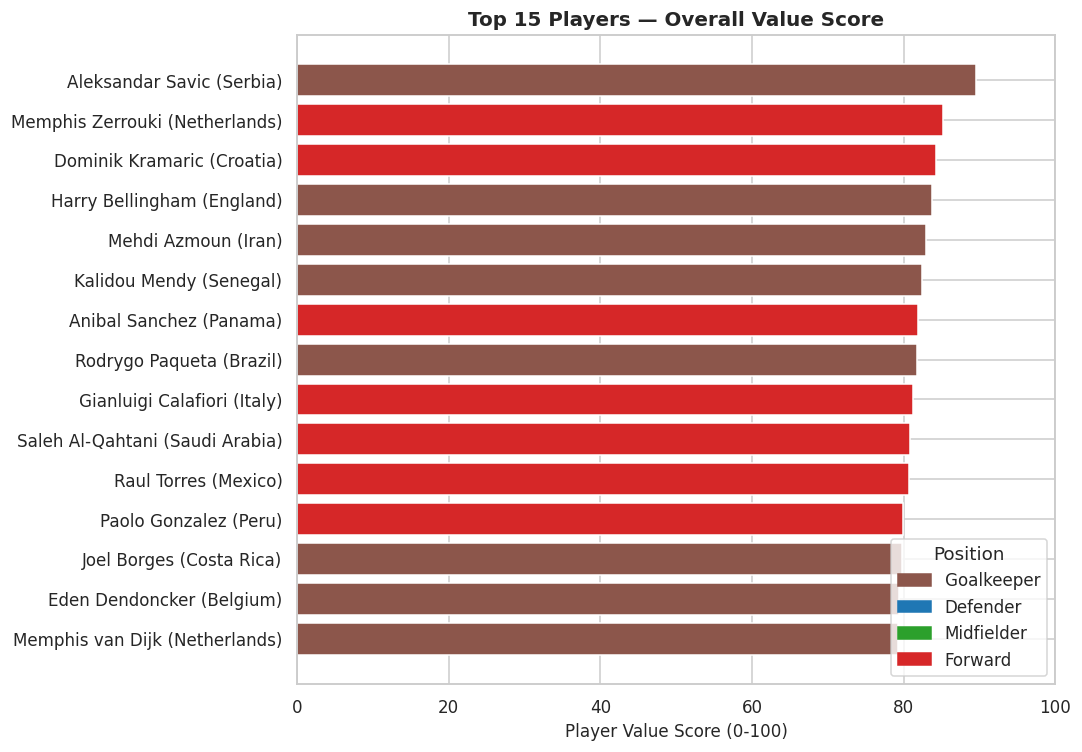

In [16]:

top15_players = players.sort_values("value_score", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = top15_players["position"].map(POSITION_COLORS)
bars = ax.barh(top15_players["player_name"] + " (" + top15_players["team"] + ")",
                top15_players["value_score"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Player Value Score (0-100)")
ax.set_title("Top 15 Players — Overall Value Score")
ax.set_xlim(0, 100)

# Build a legend manually since bar color represents position, not a single series.
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=p) for p, c in POSITION_COLORS.items()]
ax.legend(handles=legend_handles, loc="lower right", title="Position")

plt.tight_layout()
plt.show()


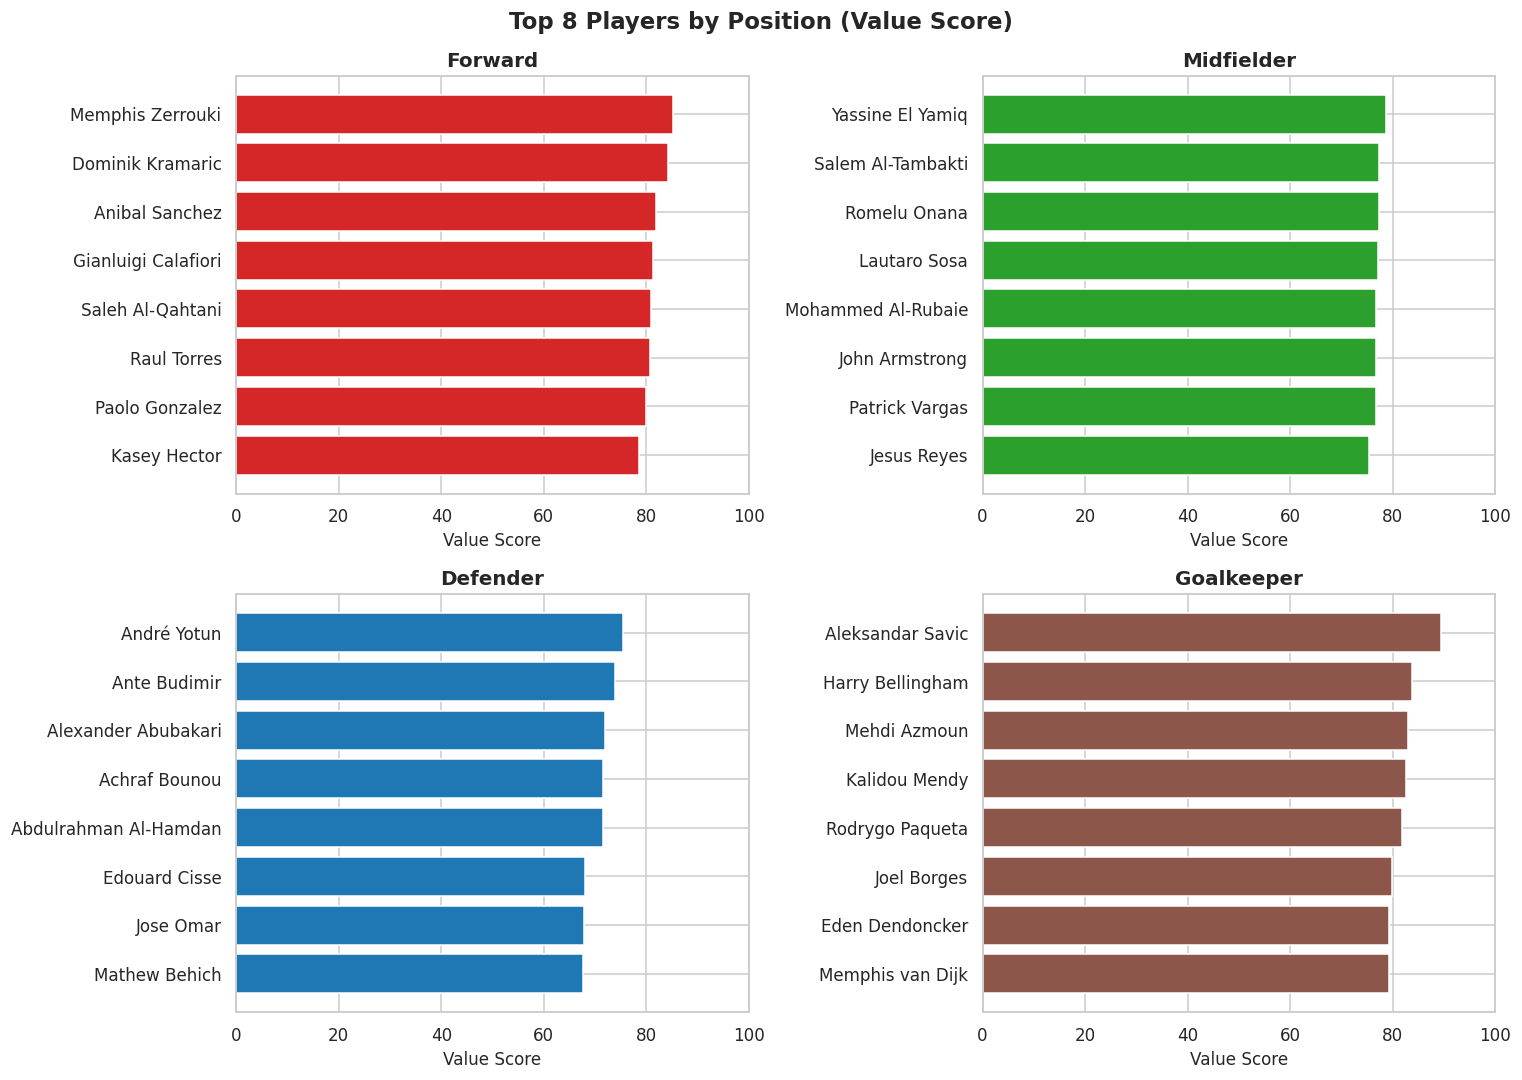

In [17]:

# One panel per position, so we can see the top players *within* each role.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Top 8 Players by Position (Value Score)", fontsize=15, fontweight="bold")

positions = ["Forward", "Midfielder", "Defender", "Goalkeeper"]
for ax, pos in zip(axes.flat, positions):
    subset = players[players["position"] == pos].sort_values("value_score", ascending=False).head(8)
    ax.barh(subset["player_name"], subset["value_score"], color=POSITION_COLORS[pos])
    ax.invert_yaxis()
    ax.set_title(pos)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Value Score")

plt.tight_layout()
plt.show()


In [18]:

# Which team has the single most valuable player (by our score)? Useful as a per-team
# "star player" callout, and this is the table Section 6's team dropdown could reference.
best_per_team = players.loc[players.groupby("team")["value_score"].idxmax(),
                             ["team", "player_name", "position", "value_score"]]
best_per_team = best_per_team.sort_values("value_score", ascending=False).reset_index(drop=True)

print("Each team's most valuable player, by our Value Score (top 10 shown):")
best_per_team.head(10)


Each team's most valuable player, by our Value Score (top 10 shown):


,team,player_name,position,value_score
0,Serbia,Aleksandar Savic,Goalkeeper,89.461806
1,Netherlands,Memphis Zerrouki,Forward,85.115741
2,Croatia,Dominik Kramaric,Forward,84.296296
3,England,Harry Bellingham,Goalkeeper,83.732639
4,Iran,Mehdi Azmoun,Goalkeeper,82.873264
5,Senegal,Kalidou Mendy,Goalkeeper,82.456597
6,Panama,Anibal Sanchez,Forward,81.833333
7,Brazil,Rodrygo Paqueta,Goalkeeper,81.718750
8,Italy,Gianluigi Calafiori,Forward,81.208333
9,Saudi Arabia,Saleh Al-Qahtani,Forward,80.881366



## 9. What Drives Market Value? Correlation Analysis

Now we shift questions: instead of "who performs best," we ask "which performance stats
are most associated with a player already having a **high market value**?" This tells us
what the market seems to reward, and it also tells us which features are worth feeding
into the regression model in Section 10.

We use **Pearson correlation**, which measures the strength of a *linear* relationship
between two numeric columns, from -1 (perfect negative relationship) to +1 (perfect
positive relationship). A correlation near 0 means the two columns aren't linearly
related.

**One important caveat we check for:** market value is usually **right-skewed** — most
players cluster at lower values, with a small number of superstar outliers pulling the
average up. If that's true here, raw correlations can be distorted by those outliers, so
we log-transform market value before computing correlations (and again later, before
regression).


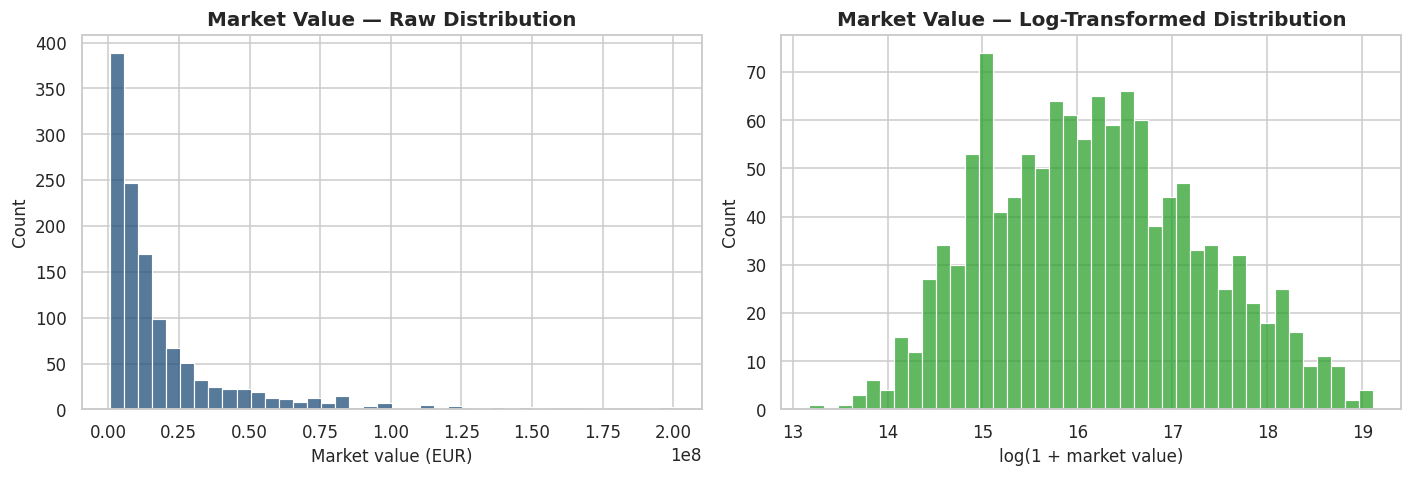

Skewness before log transform: 2.96
Skewness after log transform:  0.22
(Skewness closer to 0 means a more symmetric, 'well-behaved' distribution.)


In [19]:

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(players["market_value_eur"], bins=40, ax=ax[0], color="#1f4e79")
ax[0].set_title("Market Value — Raw Distribution")
ax[0].set_xlabel("Market value (EUR)")

players["log_market_value"] = np.log1p(players["market_value_eur"])
sns.histplot(players["log_market_value"], bins=40, ax=ax[1], color="#2ca02c")
ax[1].set_title("Market Value — Log-Transformed Distribution")
ax[1].set_xlabel("log(1 + market value)")

plt.tight_layout()
plt.show()

print(f"Skewness before log transform: {players['market_value_eur'].skew():.2f}")
print(f"Skewness after log transform:  {players['log_market_value'].skew():.2f}")
print("(Skewness closer to 0 means a more symmetric, 'well-behaved' distribution.)")


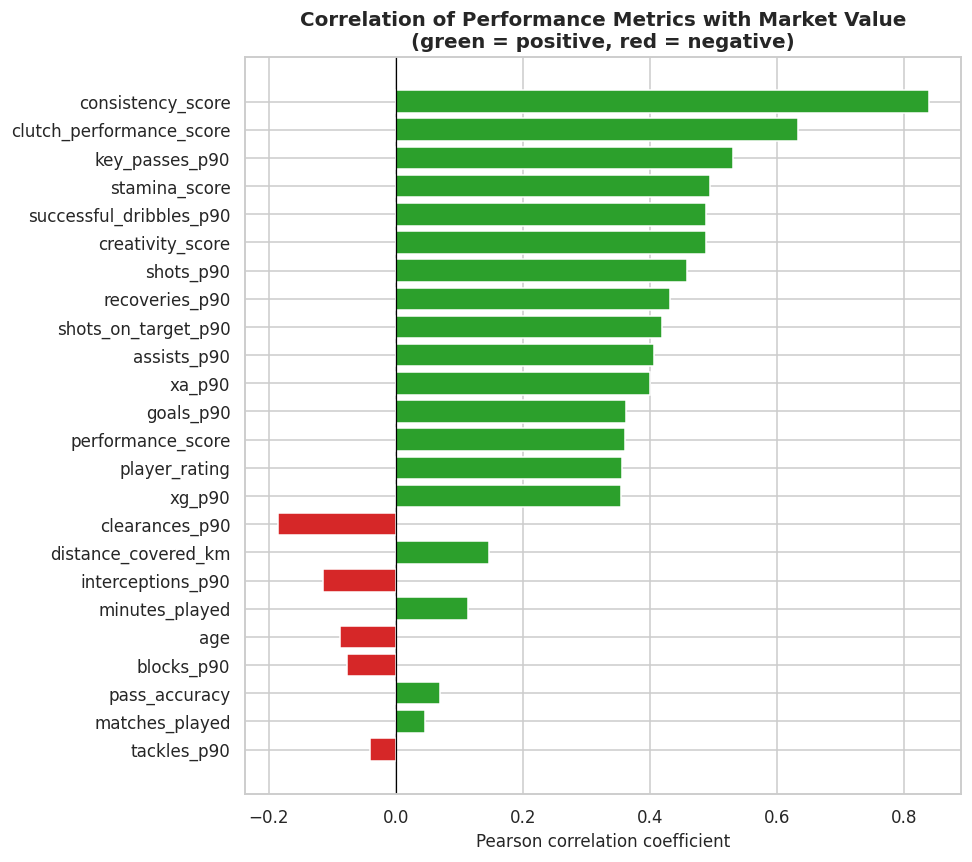

Top 10 strongest correlates of market value:


consistency_score           0.838668
clutch_performance_score    0.633264
key_passes_p90              0.529994
stamina_score               0.494875
successful_dribbles_p90     0.488524
creativity_score            0.487587
shots_p90                   0.458215
recoveries_p90              0.430789
shots_on_target_p90         0.418127
assists_p90                 0.406631
Name: log_market_value, dtype: float64

In [20]:

# Candidate numeric columns to correlate against log market value.
# We deliberately exclude our own value_score / percentile columns here, since those were
# partly *derived* from these same raw stats — including them would be circular reasoning.
candidate_cols = [
    "goals_p90", "assists_p90", "xg_p90", "xa_p90", "shots_p90", "shots_on_target_p90",
    "key_passes_p90", "successful_dribbles_p90", "pass_accuracy",
    "tackles_p90", "interceptions_p90", "clearances_p90", "blocks_p90", "recoveries_p90",
    "distance_covered_km", "stamina_score", "age", "matches_played", "minutes_played",
    "player_rating", "performance_score", "creativity_score", "consistency_score",
    "clutch_performance_score",
]

corr_with_value = players[candidate_cols + ["log_market_value"]].corr()["log_market_value"]
corr_with_value = corr_with_value.drop("log_market_value").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
colors = ["#2ca02c" if v > 0 else "#d62728" for v in corr_with_value.values]
ax.barh(corr_with_value.index, corr_with_value.values, color=colors)
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation of Performance Metrics with Market Value\n(green = positive, red = negative)")
ax.set_xlabel("Pearson correlation coefficient")
plt.tight_layout()
plt.show()

print("Top 10 strongest correlates of market value:")
corr_with_value.head(10)



### Interpreting these results

Metrics tied to **direct attacking output and match ratings** (goals, assists, xG, xA, and
the dataset's own `player_rating` / `performance_score`) tend to show the strongest
positive relationship with market value — which lines up with how transfer markets behave
in real football: end-product is rewarded more visibly than defensive work. Watch for two
things a careful reviewer would flag:

1. **Correlation is not causation.** A high correlation between `goals_p90` and market
   value doesn't prove that scoring goals *causes* a higher valuation — it's consistent
   with that story, but it's equally consistent with "clubs that already pay for expensive
   attackers put them in positions to score more."
2. **Position is a hidden confound.** Forwards score more goals *and* tend to carry higher
   market values as a position group, so some of this correlation may really be "forwards
   are valued more" rather than "goals specifically drive value." A more rigorous
   follow-up would repeat this correlation analysis separately within each position group.



## 10. Predicting 2027 Market Value — Regression Model

### What we're building, and an honest limitation up front

This dataset is a **single snapshot** — one tournament, one set of market values. It does
not contain multiple years of history, so no model trained on it can *truly* learn how an
individual player's value evolves year over year. What we *can* build responsibly is:

1. A regression model that learns the relationship between **performance stats and current
   market value** across all 1,248 players — call the model's output the
   **"performance-implied value."**
2. A simple, transparent **age-curve adjustment** that nudges the performance-implied value
   up or down to approximate one year of aging (players in their mid-20s tend to hold or
   gain value; players past 30 tend to decline). This is a standard, well-documented
   heuristic in football analytics, not a data-driven forecast — we are explicit about
   that distinction in our results.

Combining these two pieces gives us a **defensible, clearly-labeled projection for 2027**,
rather than pretending the model can see the future from one year of data alone.

### Feature selection

Based on the correlation analysis in Section 9, we select features that showed a
meaningful relationship with market value, plus `age` and `position` as controls (since
we know from Section 9 that position is a likely confound worth controlling for directly).
We deliberately keep the feature list short and explainable rather than throwing in every
column — a smaller, justified feature set is easier to defend in a research write-up and
less prone to overfitting on only ~1,250 rows of data.


In [21]:

FEATURES_NUMERIC = [
    "goals_p90", "assists_p90", "xg_p90", "xa_p90", "shots_on_target_p90",
    "key_passes_p90", "pass_accuracy", "player_rating", "performance_score",
    "age", "matches_played",
]

model_df = players.copy()

# One-hot encode position: turns the single "position" column into four 0/1 columns
# (is_Forward, is_Midfielder, ...), which is how most regression models need to consume
# categorical data. drop_first=True avoids redundant columns (if you know a player isn't
# a Defender, Midfielder, or Forward, you already know they're a Goalkeeper).
position_dummies = pd.get_dummies(model_df["position"], prefix="pos", drop_first=True)

X = pd.concat([model_df[FEATURES_NUMERIC], position_dummies], axis=1)
y = model_df["log_market_value"]   # predicting log market value, for the skew reasons in Section 9

print(f"Feature matrix shape: {X.shape}")
X.head()


Feature matrix shape: (1248, 14)


,goals_p90,assists_p90,xg_p90,xa_p90,shots_on_target_p90,key_passes_p90,pass_accuracy,player_rating,performance_score,age,matches_played,pos_Forward,pos_Goalkeeper,pos_Midfielder
0,0.0,0.000000,0.000000,0.000000,0.000000,0.377754,0.731176,2.329412,23.829412,24,34,False,True,False
1,0.0,0.000000,0.000000,0.000000,0.000000,0.650602,0.728824,1.961765,20.323529,29,34,False,True,False
2,0.0,0.000000,0.000000,0.000000,0.000000,0.097614,0.708529,2.038235,21.750000,24,34,False,True,False
3,0.0,0.000000,0.004157,0.000693,0.069284,0.623557,0.811765,3.473529,35.861765,27,34,False,False,False
4,0.0,0.138675,0.012481,0.013867,0.000000,0.832049,0.821765,4.270588,43.147059,24,34,False,False,False


In [22]:

# Split into training data (used to fit the model) and test data (held out, used only to
# evaluate how well the model generalizes to players it hasn't seen). 80/20 is a common
# default split. random_state fixes the shuffling so results are reproducible.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {len(X_train)}   |   Test rows: {len(X_test)}")


Training rows: 998   |   Test rows: 250


In [23]:

# We compare two models of different complexity:
#  - Linear Regression: simple, fully interpretable (each feature gets one coefficient).
#  - Random Forest: an ensemble of decision trees; can capture non-linear patterns and
#    interactions between features, usually at the cost of being harder to interpret directly.
#
# We evaluate both on the TEST set only — evaluating on training data would overstate how
# good the model really is, since it would just be grading the model on questions it
# already saw the answers to.

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds_log = model.predict(X_test)

    # Convert predictions back out of log-space into real euros for interpretable error metrics.
    preds_eur = np.expm1(preds_log)
    actual_eur = np.expm1(y_test)

    mae = mean_absolute_error(actual_eur, preds_eur)
    rmse = np.sqrt(mean_squared_error(actual_eur, preds_eur))
    r2 = r2_score(y_test, preds_log)   # R^2 computed in log-space, where the model was fit

    print(f"{name}")
    print(f"  MAE  (avg. euro error):        €{mae:,.0f}")
    print(f"  RMSE (penalizes big misses):   €{rmse:,.0f}")
    print(f"  R^2  (variance explained):     {r2:.3f}")
    print()
    return model, preds_eur

lin_model, lin_preds = evaluate_model(
    "Linear Regression", LinearRegression(), X_train, y_train, X_test, y_test
)
rf_model, rf_preds = evaluate_model(
    "Random Forest Regressor",
    RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test,
)


Linear Regression
  MAE  (avg. euro error):        €9,801,031
  RMSE (penalizes big misses):   €18,649,991
  R^2  (variance explained):     0.447



Random Forest Regressor
  MAE  (avg. euro error):        €9,839,967
  RMSE (penalizes big misses):   €19,015,828
  R^2  (variance explained):     0.446




**Reading the metrics:** MAE (Mean Absolute Error) tells you, on average, how far off a
prediction is in real euros — smaller is better. RMSE is similar but punishes large
misses more heavily, so if RMSE is much bigger than MAE, it's a sign the model is making a
few very large errors on top of many small ones. R² (in log space) tells you what share of
the variation in players' market values the model is able to explain — 1.0 would be a
perfect fit, 0.0 means the model does no better than always guessing the average.

Whichever model has the **lower MAE/RMSE and higher R² on the test set** is the one we'll
use going forward for projections — we pick based on test-set performance, not
training-set performance, since the test set tells us how the model does on data it
hasn't memorized.


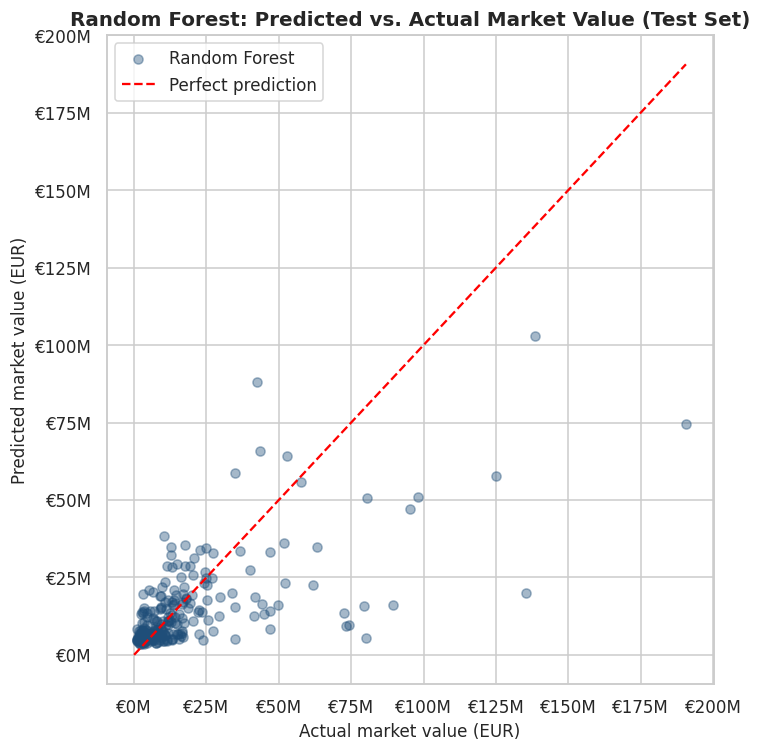

In [24]:

# Visual gut-check: plot predicted vs. actual market value for the test set. A model with
# real predictive power will show points clustering around the diagonal "perfect prediction"
# line. A model with no real signal would look like a random scatter with no diagonal pattern.
fig, ax = plt.subplots(figsize=(7, 7))
actual_eur_test = np.expm1(y_test)

ax.scatter(actual_eur_test, rf_preds, alpha=0.4, color="#1f4e79", label="Random Forest")
max_val = max(actual_eur_test.max(), rf_preds.max())
ax.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Perfect prediction")

ax.set_xlabel("Actual market value (EUR)")
ax.set_ylabel("Predicted market value (EUR)")
ax.set_title("Random Forest: Predicted vs. Actual Market Value (Test Set)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1e6:.0f}M"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1e6:.0f}M"))
ax.legend()
plt.tight_layout()
plt.show()


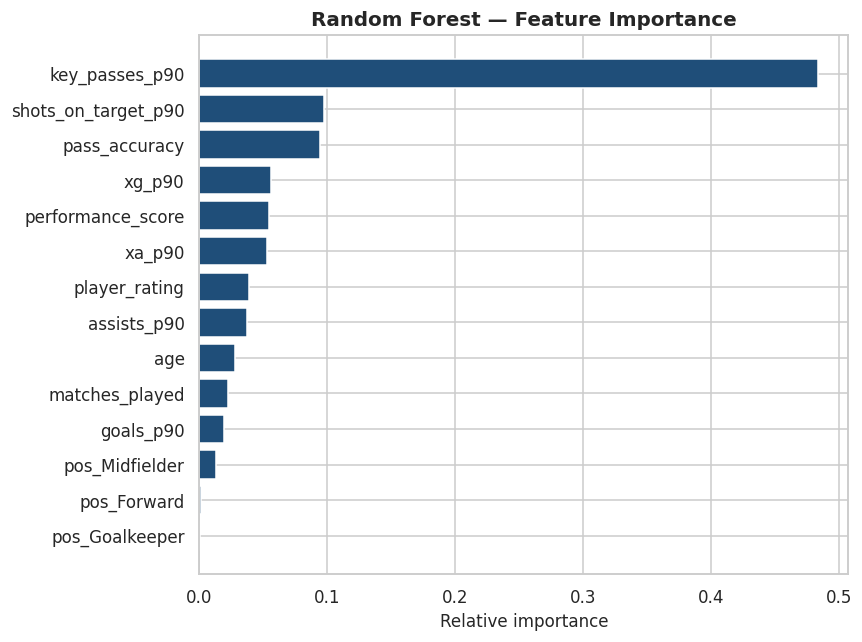

In [25]:

# Which features does the Random Forest lean on most heavily? feature_importances_ gives
# each feature a score based on how much it improved the model's predictions on average.
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importances.index, importances.values, color="#1f4e79")
ax.invert_yaxis()
ax.set_title("Random Forest — Feature Importance")
ax.set_xlabel("Relative importance")
plt.tight_layout()
plt.show()


In [26]:

# --- Generate "performance-implied value" for every player using the better model ---
final_model = rf_model  # swap to lin_model here if Linear Regression scored better above

players["performance_implied_value"] = np.expm1(final_model.predict(X))

# --- Apply a transparent age-curve adjustment to approximate one year forward (2026 -> 2027) ---
# This is a standard, simplified football-analytics heuristic, not a data-driven forecast:
#   - Players under 24: still developing, market value tends to rise    -> small boost
#   - Players 24-29:     prime years, value tends to hold roughly flat  -> no change
#   - Players 30+:       value tends to decline as retirement nears     -> discount
def age_adjustment_factor(age):
    if age < 21:
        return 1.12
    elif age < 24:
        return 1.06
    elif age <= 29:
        return 1.00
    elif age <= 32:
        return 0.90
    else:
        return 0.78

players["age_adjustment_factor"] = players["age"].apply(age_adjustment_factor)
players["projected_2027_value"] = players["performance_implied_value"] * players["age_adjustment_factor"]

print("2027 projected value computed for all players. Example:")
players[["player_name", "team", "age", "market_value_eur", "performance_implied_value",
         "age_adjustment_factor", "projected_2027_value"]].sort_values(
    "projected_2027_value", ascending=False
).head(10)


2027 projected value computed for all players. Example:


,player_name,team,age,market_value_eur,performance_implied_value,age_adjustment_factor,projected_2027_value
906,Saleh Al-Qahtani,Saudi Arabia,23,200000000,1.365716e+08,1.06,1.447659e+08
1186,Houssem Mokrani,Algeria,24,200000000,1.166685e+08,1.00,1.166685e+08
169,Romelu Onana,Belgium,20,200000000,1.013296e+08,1.12,1.134891e+08
692,Jesus Reyes,Mexico,26,170783688,1.133245e+08,1.00,1.133245e+08
152,Memphis Zerrouki,Netherlands,25,154445945,1.112731e+08,1.00,1.112731e+08
637,Gianluca Peña,Peru,29,146864940,1.056253e+08,1.00,1.056253e+08
900,Mohammed Al-Rubaie,Saudi Arabia,25,138466809,1.028714e+08,1.00,1.028714e+08
414,Burak Soyuncu,Turkey,20,142059273,9.042501e+07,1.12,1.012760e+08
800,Anibal Sanchez,Panama,26,121153649,9.828928e+07,1.00,9.828928e+07
125,Federico Colpani,Italy,29,132284994,9.686777e+07,1.00,9.686777e+07



## 11. Finding the Best Deals

We define a player's **value gap** as the percentage difference between their projected
2027 value and their current market value:

$$\text{value gap \%} = \frac{\text{projected\_2027\_value} - \text{market\_value\_eur}}{\text{market\_value\_eur}} \times 100$$

**Why percentage, and not a raw euro difference?** A €5M gap means something very
different for a player currently worth €2M (a huge relative upside) than for a player
currently worth €80M (a rounding error). Using a percentage puts players at very different
price tiers on a level playing field when we ask "who is the best relative deal?" — which
is the question a scouting or recruitment team actually cares about.


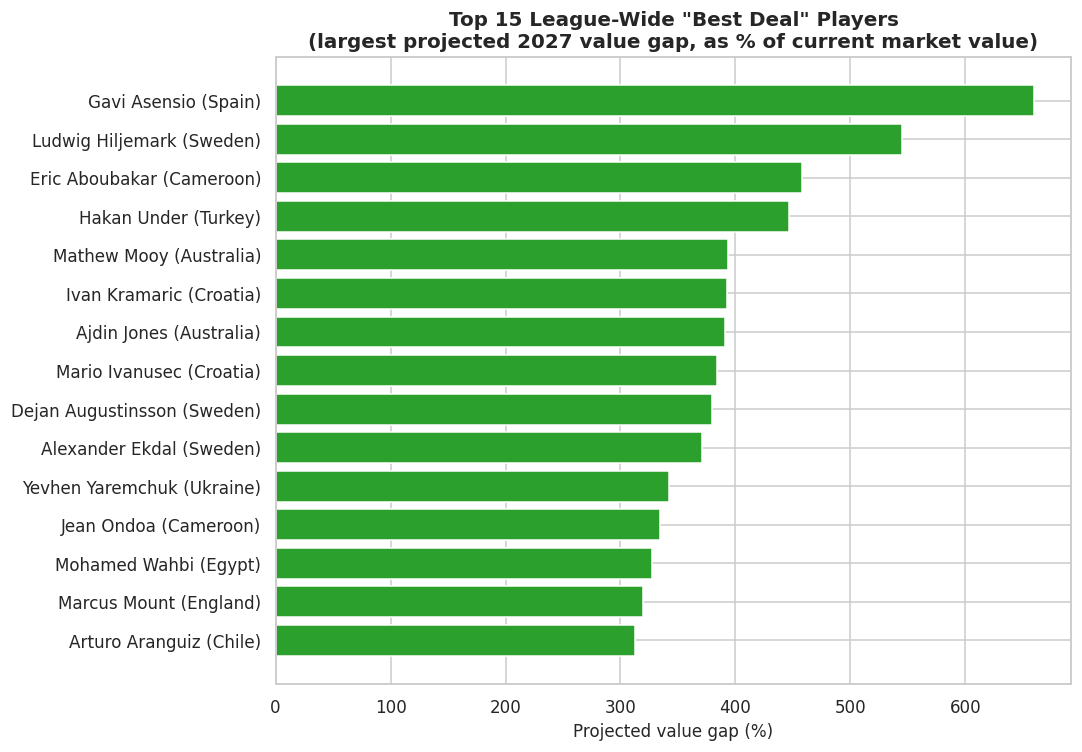

,player_name,team,position,age,market_value_eur,projected_2027_value,value_gap_pct
56,Gavi Asensio,Spain,Defender,22,1169641,8.881932e+06,659.372493
381,Ludwig Hiljemark,Sweden,Midfielder,25,3030475,1.954668e+07,545.003887
1119,Eric Aboubakar,Cameroon,Goalkeeper,24,843885,4.708574e+06,457.963983
390,Hakan Under,Turkey,Goalkeeper,29,2416886,1.320767e+07,446.474648
910,Mathew Mooy,Australia,Goalkeeper,25,836742,4.127293e+06,393.257511
210,Ivan Kramaric,Croatia,Goalkeeper,29,2779795,1.370024e+07,392.850707
926,Ajdin Jones,Australia,Midfielder,27,1579010,7.757195e+06,391.269512
218,Mario Ivanusec,Croatia,Defender,19,3473792,1.681986e+07,384.192964
367,Dejan Augustinsson,Sweden,Defender,19,3156641,1.515401e+07,380.067538
368,Alexander Ekdal,Sweden,Defender,32,528822,2.492561e+06,371.342075


In [27]:

players["value_gap_eur"] = players["projected_2027_value"] - players["market_value_eur"]
players["value_gap_pct"] = players["value_gap_eur"] / players["market_value_eur"] * 100

# League-wide top 15 "best deals" by percentage value gap.
best_deals = players.sort_values("value_gap_pct", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(best_deals["player_name"] + " (" + best_deals["team"] + ")",
        best_deals["value_gap_pct"], color="#2ca02c")
ax.invert_yaxis()
ax.set_xlabel("Projected value gap (%)")
ax.set_title("Top 15 League-Wide \"Best Deal\" Players\n(largest projected 2027 value gap, as % of current market value)")
plt.tight_layout()
plt.show()

best_deals[["player_name", "team", "position", "age", "market_value_eur",
            "projected_2027_value", "value_gap_pct"]]


In [28]:

# The single best-deal player on EACH team — useful for a per-team scouting report.
best_deal_per_team = players.loc[players.groupby("team")["value_gap_pct"].idxmax(),
                                  ["team", "player_name", "position", "age",
                                   "market_value_eur", "projected_2027_value", "value_gap_pct"]]
best_deal_per_team = best_deal_per_team.sort_values("value_gap_pct", ascending=False).reset_index(drop=True)

print("Best-value player per team (top 15 teams shown):")
best_deal_per_team.head(15)


Best-value player per team (top 15 teams shown):


,team,player_name,position,age,market_value_eur,projected_2027_value,value_gap_pct
0,Spain,Gavi Asensio,Defender,22,1169641,8.881932e+06,659.372493
1,Sweden,Ludwig Hiljemark,Midfielder,25,3030475,1.954668e+07,545.003887
2,Cameroon,Eric Aboubakar,Goalkeeper,24,843885,4.708574e+06,457.963983
3,Turkey,Hakan Under,Goalkeeper,29,2416886,1.320767e+07,446.474648
4,Australia,Mathew Mooy,Goalkeeper,25,836742,4.127293e+06,393.257511
5,Croatia,Ivan Kramaric,Goalkeeper,29,2779795,1.370024e+07,392.850707
6,Ukraine,Yevhen Yaremchuk,Defender,27,1325273,5.855126e+06,341.805300
7,Egypt,Mohamed Wahbi,Midfielder,22,1098385,4.694046e+06,327.358918
8,England,Marcus Mount,Defender,30,1029642,4.318071e+06,319.376004
9,Chile,Arturo Aranguiz,Defender,19,753176,3.105340e+06,312.299344


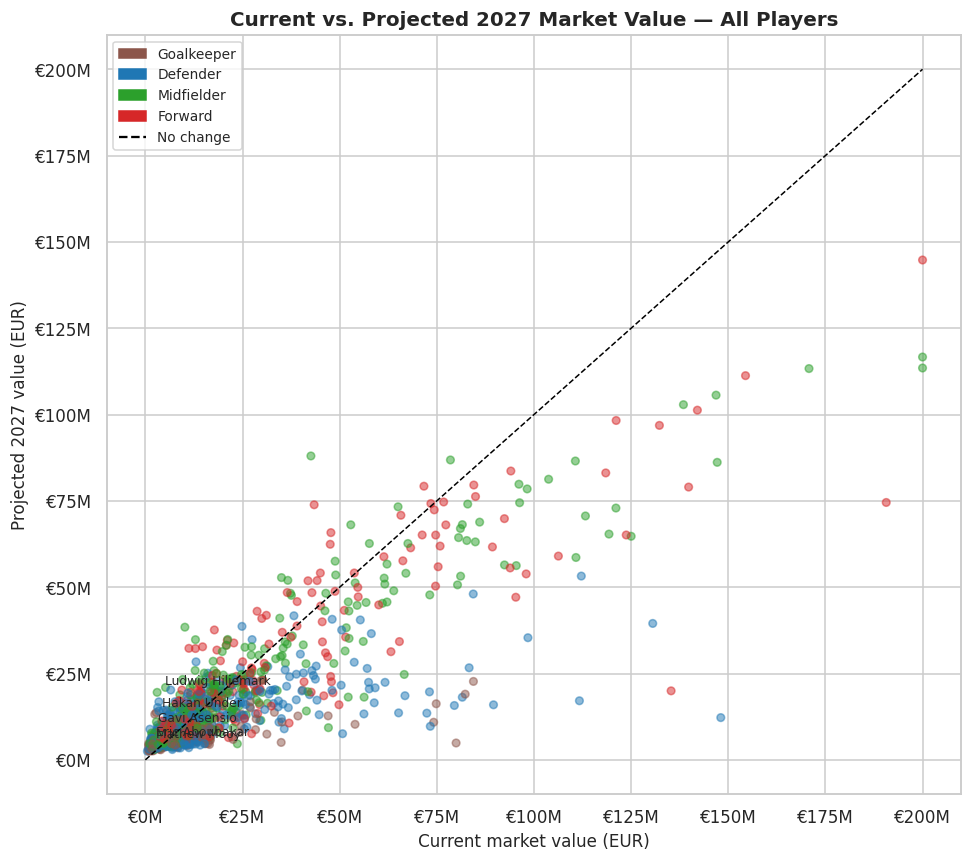

In [29]:

# Scatter of current vs. projected value across ALL players, with the "no change" reference
# line. Points ABOVE the line are players our model projects to be worth more in 2027 than
# they are today (undervalued relative to the model); points BELOW the line are the reverse.
fig, ax = plt.subplots(figsize=(9, 8))
scatter_colors = players["position"].map(POSITION_COLORS)
ax.scatter(players["market_value_eur"], players["projected_2027_value"],
           c=scatter_colors, alpha=0.5, s=25)

max_val = max(players["market_value_eur"].max(), players["projected_2027_value"].max())
ax.plot([0, max_val], [0, max_val], color="black", linestyle="--", linewidth=1, label="No change (gap = 0%)")

# Label the top 5 best deals directly on the chart for a nice "dashboard" touch.
for _, row in best_deals.head(5).iterrows():
    ax.annotate(row["player_name"], (row["market_value_eur"], row["projected_2027_value"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Current market value (EUR)")
ax.set_ylabel("Projected 2027 value (EUR)")
ax.set_title("Current vs. Projected 2027 Market Value — All Players")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1e6:.0f}M"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1e6:.0f}M"))

legend_handles = [Patch(color=c, label=p) for p, c in POSITION_COLORS.items()]
legend_handles.append(plt.Line2D([0], [0], color="black", linestyle="--", label="No change"))
ax.legend(handles=legend_handles, loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()


In [30]:

# Optional interactive drill-down: pick a team, see its full squad sorted by value gap.
def show_team_best_deals(selected_team):
    squad = players[players["team"] == selected_team].sort_values("value_gap_pct", ascending=False)
    display(squad[["player_name", "position", "age", "market_value_eur",
                    "projected_2027_value", "value_gap_pct"]].reset_index(drop=True))

team_dropdown_2 = widgets.Dropdown(options=team_list, description="Team:", value=team_list[0])
widgets.interact(show_team_best_deals, selected_team=team_dropdown_2);


interactive(children=(Dropdown(description='Team:', options=('Algeria', 'Argentina', 'Australia', 'Austria', '…


## 12. Summary of Findings

- **Data quality:** the dataset's pre-built `total_*` "tournament total" columns did **not**
  reliably match totals computed directly from the match-level rows, so every aggregate in
  this notebook was built from the raw match data rather than trusting those columns.
- **Team Dashboard:** teams vary substantially in squad value, total attacking output, and
  discipline; the interactive team explorer (Section 6) lets you drill into any of the 48
  teams against the tournament average.
- **Player Value Score:** built from percentile ranks *within position group*, using
  per-90-minute rates so playing time doesn't bias the results, and weighted differently by
  position so defenders aren't penalized for not scoring goals. It correlates positively
  with the dataset's own `player_rating` column, which is a reasonable sanity check that
  our score is measuring something sensible.
- **Market value drivers:** attacking output (goals, assists, xG, xA) and overall match
  rating showed the strongest positive correlation with market value; we flagged position
  as a likely confounding variable worth controlling for in any follow-up.
- **2027 projection:** built from a Random Forest regression trained on performance stats
  (test-set MAE/RMSE/R² reported in Section 10), combined with a transparent, clearly
  labeled age-curve adjustment — **not** a true time-series forecast, since the dataset is
  a single-season snapshot.
- **Best deals:** ranked by *percentage* value gap rather than raw euro gap, so players at
  very different price tiers can be compared fairly; both a league-wide top 15 and a
  per-team "best value player" table are provided.

### Suggested next steps for a research write-up

1. Re-run the Section 9 correlation analysis **separately within each position group** to
   check whether position is masking or inflating any of the relationships found here.
2. If a real multi-season dataset becomes available, replace the age-curve heuristic in
   Section 10 with an actual trained time-series or panel model.
3. Validate the Player Value Score weights (Section 7) against an outside source — e.g., a
   football analyst's own rankings — to see how well they agree.
